**1. Préparation des données**

In [13]:
# Importer les bibliothèque néccessaire
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_excel('US_Superstore_data.xls')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# le prétraitement de base des données.
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [9]:
# Effectuer le nettoyage et le prétraitement de base des données.
df_cleaned = df.dropna()
# df_cleaned.info()

df_cleaned['Sales'] = pd.to_numeric(df_cleaned['Sales'], errors='coerce')
df_cleaned['Profit'] = pd.to_numeric(df_cleaned['Profit'], errors='coerce')
df_cleaned.info()


<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

**2. Visualisation des données avec Matplotlib**

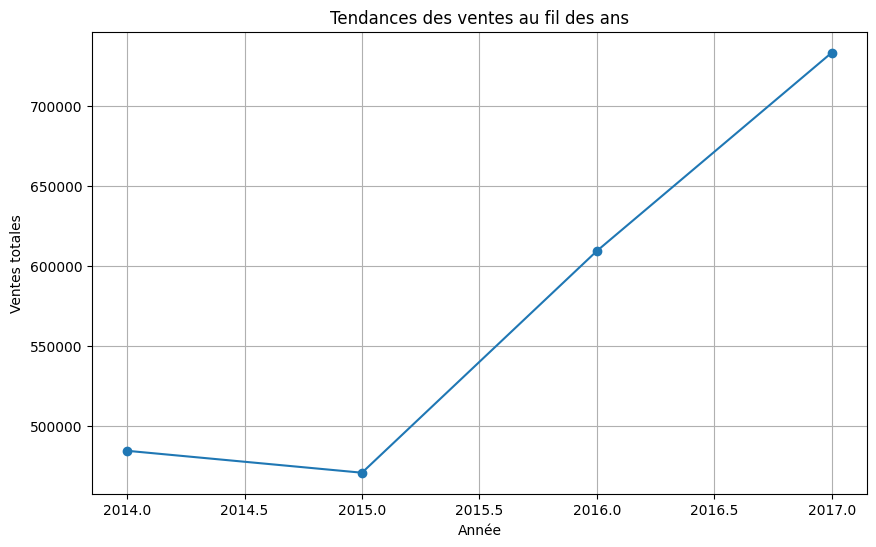

In [10]:
# Créez un graphique linéaire interactif pour illustrer les tendances des ventes au fil des ans
df_cleaned['Order Date'] = pd.to_datetime(df_cleaned['Order Date'], errors='coerce')
df_cleaned['Year'] = df_cleaned['Order Date'].dt.year
sales_by_year = df_cleaned.groupby('Year')['Sales'].sum().reset_index()
plt.figure(figsize=(10, 6))
plt.plot(sales_by_year['Year'], sales_by_year['Sales'], marker='o')
plt.title('Tendances des ventes au fil des ans')
plt.xlabel('Année')
plt.ylabel('Ventes totales')
plt.grid()
plt.show()

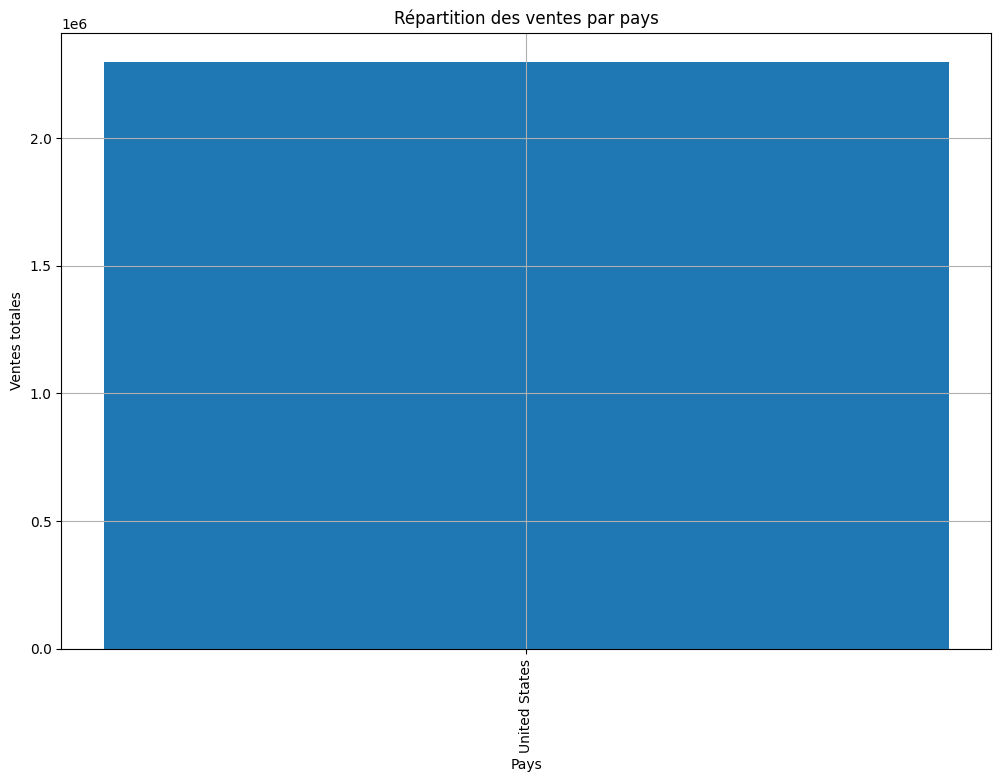

In [11]:
# Créez une carte interactive pour visualiser la répartition des ventes par pays
sales_by_country = df_cleaned.groupby('Country')['Sales'].sum().reset_index()
plt.figure(figsize=(12, 8))
plt.bar(sales_by_country['Country'], sales_by_country['Sales'])
plt.title('Répartition des ventes par pays')
plt.xlabel('Pays')
plt.ylabel('Ventes totales')
plt.xticks(rotation=90)
plt.grid()
plt.show()

**3. Visualisation des données avec Seaborn**

C:\Users\USER\AppData\Local\Temp\ipykernel_14716\2261181066.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sales', y='Product Name', data=top_products, palette='viridis')


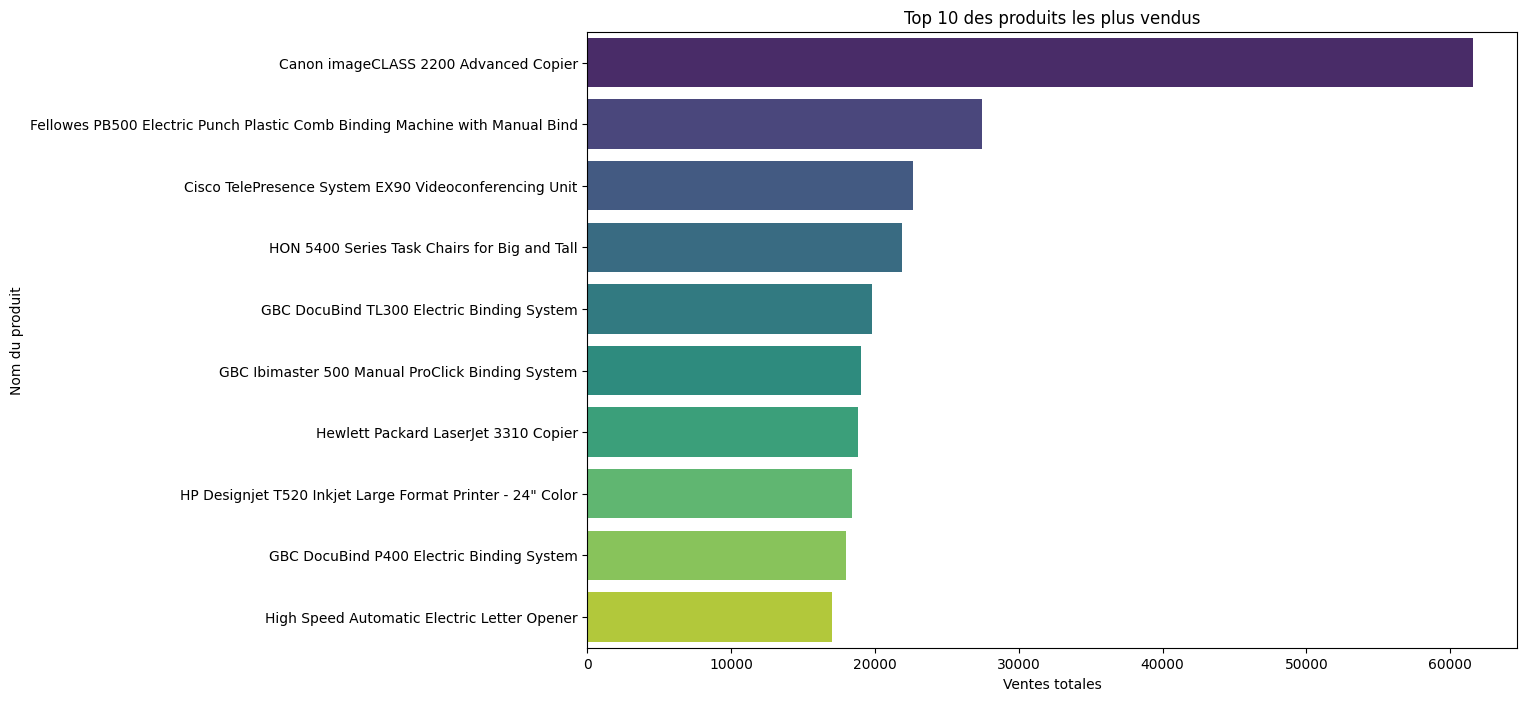

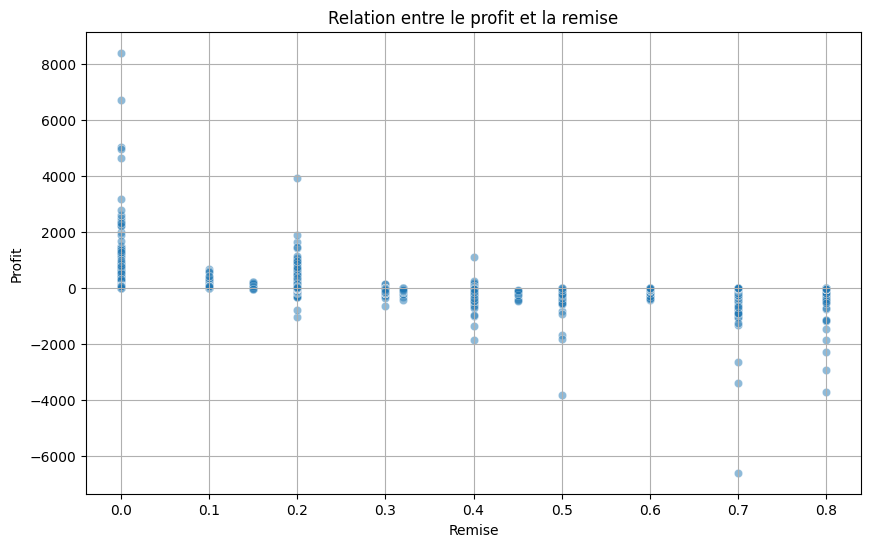

In [14]:
# Utilisez Seaborn pour générer un graphique à barres affichant les 10 produits les plus vendus.
top_products = df_cleaned.groupby('Product Name')['Sales'].sum().nlargest(10).reset_index()
plt.figure(figsize=(12, 8))
sns.barplot(x='Sales', y='Product Name', data=top_products, palette='viridis')
plt.title('Top 10 des produits les plus vendus')
plt.xlabel('Ventes totales')
plt.ylabel('Nom du produit')
plt.show()

# Créez un nuage de points pour analyser la relation entre le profit et la remise
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Discount', y='Profit', data=df_cleaned, alpha=0.5)
plt.title('Relation entre le profit et la remise')
plt.xlabel('Remise')
plt.ylabel('Profit')
plt.grid()
plt.show()

**4. Analyse comparative**

Comparez les informations obtenues grâce aux visualisations Matplotlib et Seaborn.

 - Avec les informations obtenues avec les deux bibliothèques matplotlib et seaborn, on peut conclure que les ventes sont plus élevées dans les pays suivants : United States, Canada, France, United Kingdom, Germany, Australia, Spain, Italy, Belgium et Netherlands. Cependant, il est important de noter que les données peuvent être influencées par divers facteurs tels que la population, le pouvoir d'achat et les préférences des consommateurs dans chaque pays. Par conséquent, il serait utile d'explorer davantage ces facteurs pour mieux comprendre les raisons derrière ces tendances de vente.

Consignez vos observations concernant la facilité d'utilisation et l'efficacité des deux outils.
    - En ce qui concerne la facilité d'utilisation, Matplotlib est une bibliothèque de visualisation de données très puissante et flexible, mais elle peut être un peu plus complexe à utiliser pour les débutants en raison de sa syntaxe plus détaillée. D'un autre côté, Seaborn est construit sur Matplotlib et offre une interface plus simple et plus intuitive pour créer des visualisations statistiques, ce qui le rend plus accessible pour les utilisateurs moins expérimentés.